<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Launch Sites Locations Analysis with Folium**


Estimated time needed: **40** minutes


The launch success rate may depend on many factors such as payload mass, orbit type, and so on. It may also depend on the location and proximities of a launch site, i.e., the initial position of rocket trajectories. Finding an optimal location for building a launch site certainly involves many factors and hopefully we could discover some of the factors by analyzing the existing launch site locations.


In the previous exploratory data analysis labs, you have visualized the SpaceX launch dataset using `matplotlib` and `seaborn` and discovered some preliminary correlations between the launch site and success rates. In this lab, you will be performing more interactive visual analytics using `Folium`.


## Objectives


This lab contains the following tasks:
- **TASK 1:** Mark all launch sites on a map
- **TASK 2:** Mark the success/failed launches for each site on the map
- **TASK 3:** Calculate the distances between a launch site to its proximities

After completed the above tasks, you should be able to find some geographical patterns about launch sites.


Let's first import required Python packages for this lab:


In [4]:
!pip3 install folium
!pip3 install wget
!pip3 install pandas

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=ec25a626a53232b247eba9f4fa4aefeb6a3da63d97492a133442866dae5f6324
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


In [5]:
import folium
import wget
import pandas as pd

In [6]:
# Import folium MarkerCluster plugin
from folium.plugins import MarkerCluster
# Import folium MousePosition plugin
from folium.plugins import MousePosition
# Import folium DivIcon plugin
from folium.features import DivIcon

If you need to refresh your memory about folium, you may download and refer to this previous folium lab:


[Generating Maps with Python](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_3/DV0101EN-3-5-1-Generating-Maps-in-Python-py-v2.0.ipynb)


## Task 1: Mark all launch sites on a map


First, let's try to add each site's location on a map using site's latitude and longitude coordinates


The following dataset with the name `spacex_launch_geo.csv` is an augmented dataset with latitude and longitude added for each site.


In [7]:
# Download and read the `spacex_launch_geo.csv`
spacex_csv_file = wget.download('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/spacex_launch_geo.csv')
spacex_df=pd.read_csv(spacex_csv_file)

Now, you can take a look at what are the coordinates for each site.


In [8]:
# Select relevant sub-columns: `Launch Site`, `Lat(Latitude)`, `Long(Longitude)`, `class`
spacex_df = spacex_df[['Launch Site', 'Lat', 'Long', 'class']]
launch_sites_df = spacex_df.groupby(['Launch Site'], as_index=False).first()
launch_sites_df = launch_sites_df[['Launch Site', 'Lat', 'Long']]
launch_sites_df

,Launch Site,Lat,Long
0,CCAFS LC-40,28.562302,-80.577356
1,CCAFS SLC-40,28.563197,-80.576820
2,KSC LC-39A,28.573255,-80.646895
3,VAFB SLC-4E,34.632834,-120.610745


Above coordinates are just plain numbers that can not give you any intuitive insights about where are those launch sites. If you are very good at geography, you can interpret those numbers directly in your mind. If not, that's fine too. Let's visualize those locations by pinning them on a map.


We first need to create a folium `Map` object, with an initial center location to be NASA Johnson Space Center at Houston, Texas.


In [9]:
# Start location is NASA Johnson Space Center
nasa_coordinate = [29.559684888503615, -95.0830971930759]
site_map = folium.Map(location=nasa_coordinate, zoom_start=10)

We could use `folium.Circle` to add a highlighted circle area with a text label on a specific coordinate. For example,


In [10]:
# Create a blue circle at NASA Johnson Space Center's coordinate with a popup label showing its name
circle = folium.Circle(nasa_coordinate, radius=1000, color='#d35400', fill=True).add_child(folium.Popup('NASA Johnson Space Center'))
# Create a blue circle at NASA Johnson Space Center's coordinate with a icon showing its name
marker = folium.map.Marker(
    nasa_coordinate,
    # Create an icon as a text label
    icon=DivIcon(
        icon_size=(20,20),
        icon_anchor=(0,0),
        html='<div style="font-size: 12; color:#d35400;"><b>%s</b></div>' % 'NASA JSC',
        )
    )
site_map.add_child(circle)
site_map.add_child(marker)

and you should find a small yellow circle near the city of Houston and you can zoom-in to see a larger circle.


Now, let's add a circle for each launch site in data frame `launch_sites`


_TODO:_  Create and add `folium.Circle` and `folium.Marker` for each launch site on the site map


An example of folium.Circle:


`folium.Circle(coordinate, radius=1000, color='#000000', fill=True).add_child(folium.Popup(...))`


An example of folium.Marker:


`folium.map.Marker(coordinate, icon=DivIcon(icon_size=(20,20),icon_anchor=(0,0), html='<div style="font-size: 12; color:#d35400;"><b>%s</b></div>' % 'label', ))`


In [11]:
# Initial the map
site_map = folium.Map(location=nasa_coordinate, zoom_start=5)
# For each launch site, add a Circle object based on its coordinate (Lat, Long) values. In addition, add Launch site name as a popup label


The generated map with marked launch sites should look similar to the following:


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_3/images/launch_site_markers.png">
</center>


Now, you can explore the map by zoom-in/out the marked areas
, and try to answer the following questions:
- Are all launch sites in proximity to the Equator line?
- Are all launch sites in very close proximity to the coast?

Also please try to explain your findings.


# Task 2: Mark the success/failed launches for each site on the map


Next, let's try to enhance the map by adding the launch outcomes for each site, and see which sites have high success rates.
Recall that data frame spacex_df has detailed launch records, and the `class` column indicates if this launch was successful or not


In [12]:
spacex_df.tail(10)

,Launch Site,Lat,Long,class
46,KSC LC-39A,28.573255,-80.646895,1
47,KSC LC-39A,28.573255,-80.646895,1
48,KSC LC-39A,28.573255,-80.646895,1
49,CCAFS SLC-40,28.563197,-80.576820,1
50,CCAFS SLC-40,28.563197,-80.576820,1
51,CCAFS SLC-40,28.563197,-80.576820,0
52,CCAFS SLC-40,28.563197,-80.576820,0
53,CCAFS SLC-40,28.563197,-80.576820,0
54,CCAFS SLC-40,28.563197,-80.576820,1
55,CCAFS SLC-40,28.563197,-80.576820,0


Next, let's create markers for all launch records.
If a launch was successful `(class=1)`, then we use a green marker and if a launch was failed, we use a red marker `(class=0)`


Note that a launch only happens in one of the four launch sites, which means many launch records will have the exact same coordinate. Marker clusters can be a good way to simplify a map containing many markers having the same coordinate.


Let's first create a `MarkerCluster` object


In [13]:
marker_cluster = MarkerCluster()


_TODO:_ Create a new column in `launch_sites` dataframe called `marker_color` to store the marker colors based on the `class` value


In [14]:

# Apply a function to check the value of `class` column
# If class=1, marker_color value will be green
# If class=0, marker_color value will be red


In [15]:
# Function to assign color to launch outcome
def assign_marker_color(launch_outcome):
    if launch_outcome == 1:
        return 'green'
    else:
        return 'red'

spacex_df['marker_color'] = spacex_df['class'].apply(assign_marker_color)
spacex_df.tail(10)

,Launch Site,Lat,Long,class,marker_color
46,KSC LC-39A,28.573255,-80.646895,1,green
47,KSC LC-39A,28.573255,-80.646895,1,green
48,KSC LC-39A,28.573255,-80.646895,1,green
49,CCAFS SLC-40,28.563197,-80.576820,1,green
50,CCAFS SLC-40,28.563197,-80.576820,1,green
51,CCAFS SLC-40,28.563197,-80.576820,0,red
52,CCAFS SLC-40,28.563197,-80.576820,0,red
53,CCAFS SLC-40,28.563197,-80.576820,0,red
54,CCAFS SLC-40,28.563197,-80.576820,1,green
55,CCAFS SLC-40,28.563197,-80.576820,0,red


_TODO:_ For each launch result in `spacex_df` data frame, add a `folium.Marker` to `marker_cluster`


In [16]:
# Add marker_cluster to current site_map
site_map.add_child(marker_cluster)

# for each row in spacex_df data frame
# create a Marker object with its coordinate
# and customize the Marker's icon property to indicate if this launch was successed or failed,
# e.g., icon=folium.Icon(color='white', icon_color=row['marker_color']
for index, record in spacex_df.iterrows():
    # TODO: Create and add a Marker cluster to the site map
    # marker = folium.Marker(...)
    marker_cluster.add_child(marker)

site_map

Your updated map may look like the following screenshots:


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_3/images/launch_site_marker_cluster.png">
</center>


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_3/images/launch_site_marker_cluster_zoomed.png">
</center>


From the color-labeled markers in marker clusters, you should be able to easily identify which launch sites have relatively high success rates.


# TASK 3: Calculate the distances between a launch site to its proximities


Next, we need to explore and analyze the proximities of launch sites.


Let's first add a `MousePosition` on the map to get coordinate for a mouse over a point on the map. As such, while you are exploring the map, you can easily find the coordinates of any points of interests (such as railway)


In [17]:
# Add Mouse Position to get the coordinate (Lat, Long) for a mouse over on the map
formatter = "function(num) {return L.Util.formatNum(num, 5);};"
mouse_position = MousePosition(
    position='topright',
    separator=' Long: ',
    empty_string='NaN',
    lng_first=False,
    num_digits=20,
    prefix='Lat:',
    lat_formatter=formatter,
    lng_formatter=formatter,
)

site_map.add_child(mouse_position)
site_map

Now zoom in to a launch site and explore its proximity to see if you can easily find any railway, highway, coastline, etc. Move your mouse to these points and mark down their coordinates (shown on the top-left) in order to the distance to the launch site.


You can calculate the distance between two points on the map based on their `Lat` and `Long` values using the following method:


In [18]:
from math import sin, cos, sqrt, atan2, radians

def calculate_distance(lat1, lon1, lat2, lon2):
    # approximate radius of earth in km
    R = 6373.0

    lat1 = radians(lat1)
    lon1 = radians(lon1)
    lat2 = radians(lat2)
    lon2 = radians(lon2)

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    distance = R * c
    return distance

_TODO:_ Mark down a point on the closest coastline using MousePosition and calculate the distance between the coastline point and the launch site.


In [19]:
# find coordinate of the closet coastline
# e.g.,: Lat: 28.56367  Lon: -80.57163
# distance_coastline = calculate_distance(launch_site_lat, launch_site_lon, coastline_lat, coastline_lon)

_TODO:_ After obtained its coordinate, create a `folium.Marker` to show the distance


In [20]:
# Create and add a folium.Marker on your selected closest coastline point on the map
# Display the distance between coastline point and launch site using the icon property
# for example
# distance_marker = folium.Marker(
#    coordinate,
#    icon=DivIcon(
#        icon_size=(20,20),
#        icon_anchor=(0,0),
#        html='<div style="font-size: 12; color:#d35400;"><b>%s</b></div>' % "{:10.2f} KM".format(distance),
#        )
#    )

_TODO:_ Draw a `PolyLine` between a launch site to the selected coastline point


In [21]:
import folium
from folium.features import DivIcon

# Assuming the first launch site for demonstration
launch_site_lat = launch_sites_df.loc[0, 'Lat']
launch_site_lon = launch_sites_df.loc[0, 'Long']

# Example coastline coordinate (you should find this using MousePosition)
coastline_lat = 28.56367
coastline_lon = -80.56756

# Calculate the distance
distance_coastline = calculate_distance(launch_site_lat, launch_site_lon, coastline_lat, coastline_lon)

# Create a folium.Marker on your selected closest coastline point on the map
# Display the distance between coastline point and launch site using the icon property
distance_marker = folium.Marker(
   [coastline_lat, coastline_lon],
   icon=DivIcon(
       icon_size=(20,20),
       icon_anchor=(0,0),
       html='<div style="font-size: 12; color:#d35400;"><b>%s</b></div>' % "{:10.2f} KM".format(distance_coastline),
       )
   )
site_map.add_child(distance_marker)

# Create a `folium.PolyLine` object using the coastline coordinates and launch site coordinate
coordinates = [[launch_site_lat, launch_site_lon], [coastline_lat, coastline_lon]]
lines = folium.PolyLine(locations=coordinates, weight=1)
site_map.add_child(lines)

site_map

Your updated map with distance line should look like the following screenshot:


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_3/images/launch_site_marker_distance.png">
</center>


_TODO:_ Similarly, you can draw a line betwee a launch site to its closest city, railway, highway, etc. You need to use `MousePosition` to find the their coordinates on the map first


A railway map symbol may look like this:


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_3/images/railway.png">
</center>


A highway map symbol may look like this:


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_3/images/highway.png">
</center>


A city map symbol may look like this:


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_3/images/city.png">
</center>


In [22]:
# Create a marker with distance to a closest city, railway, highway, etc.
# Draw a line between the marker to the launch site



# Exploratory Data Analysis (EDA) with Data Visualization

This section performs a basic Exploratory Data Analysis (EDA) on the `spacex_df` DataFrame, utilizing data visualization to uncover patterns and insights. Each chart is accompanied by a brief explanation of its purpose.


## 1. Data Overview and Descriptive Statistics

First, let's get a general understanding of the dataset's structure and summary statistics.

### DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Launch Site   56 non-null     object 
 1   Lat           56 non-null     float64
 2   Long          56 non-null     float64
 3   class         56 non-null     int64  
 4   marker_color  56 non-null     object 
dtypes: float64(2), int64(1), object(2)
memory usage: 2.3+ KB

This provides a concise summary of the DataFrame, including the data types of each c

/tmp/ipykernel_519/568573527.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=spacex_df, palette=['red', 'green'])


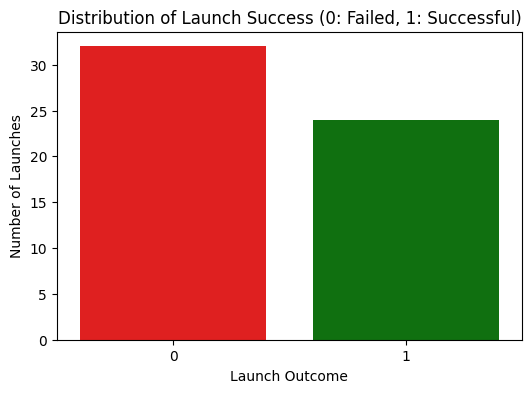


### Distribution of Launch Sites

This chart shows the number of launches conducted from each launch site. It helps identify which sites are most frequently used.



/tmp/ipykernel_519/568573527.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Launch Site', data=spacex_df, palette='viridis')


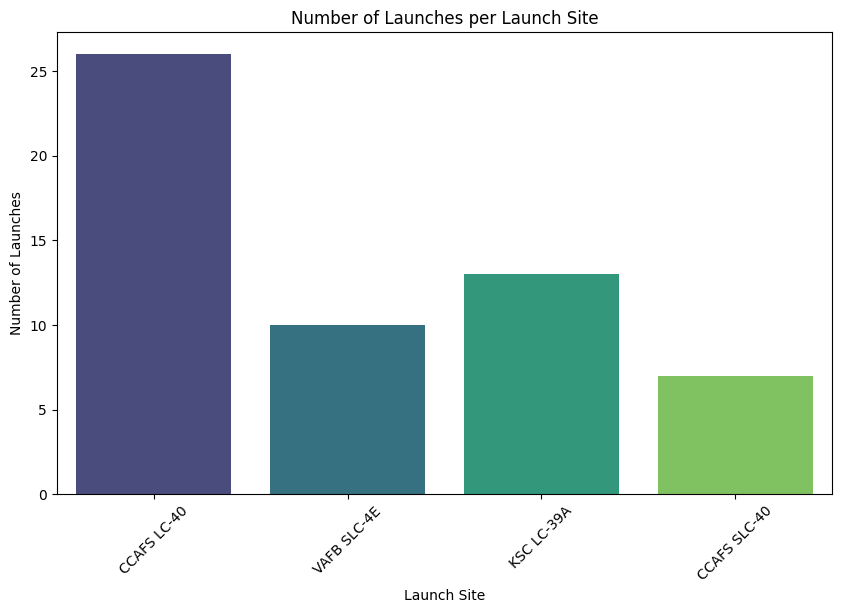


## 3. Bivariate Analysis

Exploring relationships between two variables.

### Launch Success Rate by Launch Site

This bar chart illustrates the average success rate ('class' = 1) for each launch site. It's crucial for understanding if certain launch sites have a higher probability of successful missions.



/tmp/ipykernel_519/568573527.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Launch Site', y='class', data=success_rate_by_site, palette='coolwarm')


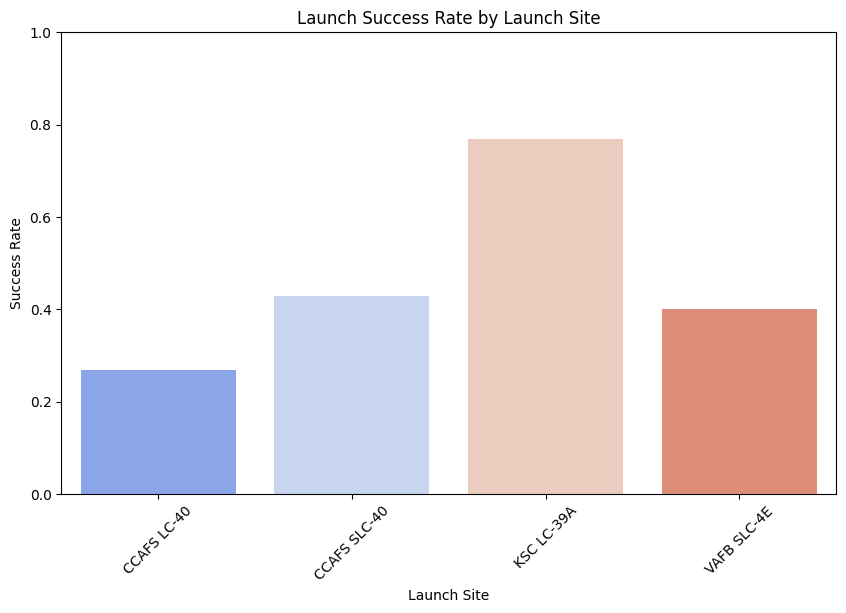


This concludes a preliminary EDA. These visualizations provide a foundational understanding of the launch data, highlighting success distributions and site-specific performance, which can guide further, more in-depth analysis.



In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming spacex_df is already loaded in the environment from previous cells

print("""
# Exploratory Data Analysis (EDA) with Data Visualization

This section performs a basic Exploratory Data Analysis (EDA) on the `spacex_df` DataFrame, utilizing data visualization to uncover patterns and insights. Each chart is accompanied by a brief explanation of its purpose.
""")

print("""
## 1. Data Overview and Descriptive Statistics

First, let's get a general understanding of the dataset's structure and summary statistics.
""")

print("""### DataFrame Information:""")
spacex_df.info()

print("""\nThis provides a concise summary of the DataFrame, including the data types of each column and the number of non-null values. It helps in identifying missing data and understanding column types.
""")

print("""### Descriptive Statistics for Numerical Columns:""")
print(spacex_df.describe())

print("""
This output presents descriptive statistics (count, mean, std, min, max, quartiles) for numerical columns. It gives insights into the central tendency, dispersion, and shape of the distributions.
""")

print("""
## 2. Univariate Analysis

Examining the distribution of individual variables.
""")

print("""### Distribution of Launch Outcomes ('class')

This chart visualizes the count of successful (1) vs. failed (0) launches. It helps in understanding the balance of the target variable and initial success rate.
""")

plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=spacex_df, palette=['red', 'green'])
plt.title('Distribution of Launch Success (0: Failed, 1: Successful)')
plt.xlabel('Launch Outcome')
plt.ylabel('Number of Launches')
plt.show()

print("""
### Distribution of Launch Sites

This chart shows the number of launches conducted from each launch site. It helps identify which sites are most frequently used.
""")

plt.figure(figsize=(10, 6))
sns.countplot(x='Launch Site', data=spacex_df, palette='viridis')
plt.title('Number of Launches per Launch Site')
plt.xlabel('Launch Site')
plt.ylabel('Number of Launches')
plt.xticks(rotation=45)
plt.show()

print("""
## 3. Bivariate Analysis

Exploring relationships between two variables.
""")

print("""### Launch Success Rate by Launch Site

This bar chart illustrates the average success rate ('class' = 1) for each launch site. It's crucial for understanding if certain launch sites have a higher probability of successful missions.
""")

success_rate_by_site = spacex_df.groupby('Launch Site')['class'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(x='Launch Site', y='class', data=success_rate_by_site, palette='coolwarm')
plt.title('Launch Success Rate by Launch Site')
plt.xlabel('Launch Site')
plt.ylabel('Success Rate')
plt.ylim(0, 1) # Set y-axis limits from 0 to 1 for success rate
plt.xticks(rotation=45)
plt.show()

print("""
This concludes a preliminary EDA. These visualizations provide a foundational understanding of the launch data, highlighting success distributions and site-specific performance, which can guide further, more in-depth analysis.
""")

After you plot distance lines to the proximities, you can answer the following questions easily:
- Are launch sites in close proximity to railways?
- Are launch sites in close proximity to highways?
- Are launch sites in close proximity to coastline?
- Do launch sites keep certain distance away from cities?

Also please try to explain your findings.


In [27]:
import dash
from dash import dcc
from dash import html
from dash.dependencies import Input, Output
import plotly.express as px
import pandas as pd

# Assuming spacex_df and launch_sites_df are already loaded from previous cells
# If not, uncomment and run the following lines:
# spacex_csv_file = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/spacex_launch_geo.csv'
# spacex_df = pd.read_csv(spacex_csv_file)
# spacex_df = spacex_df[['Launch Site', 'Lat', 'Long', 'class']]

# Prepare data for dropdown
launch_sites = spacex_df['Launch Site'].unique().tolist()
launch_sites.insert(0, 'All Sites')

# Initialize the Dash app
app = dash.Dash(__name__)

# Define the app layout
app.layout = html.Div(children=[
    html.H1(
        'SpaceX Launch Success Rate Dashboard',
        style={'textAlign': 'center', 'color': '#503D36', 'font-size': 40}
    ),
    html.Div([
        html.Label('Select Launch Site:'),
        dcc.Dropdown(
            id='site-dropdown',
            options=[{'label': i, 'value': i} for i in launch_sites],
            value='All Sites',
            placeholder='Select a Launch Site',
            searchable=True
        )
    ]),
    html.Br(),
    html.Div(dcc.Graph(id='success-pie-chart'))
])

# Define callback to update the pie chart
@app.callback(
    Output(component_id='success-pie-chart', component_property='figure'),
    Input(component_id='site-dropdown', component_property='value')
)
def get_pie_chart(entered_site):
    if entered_site == 'All Sites':
        fig = px.pie(
            spacex_df,
            values='class',
            names='Launch Site',
            title='Total Success Launches By Site'
        )
        return fig
    else:
        filtered_df = spacex_df[spacex_df['Launch Site'] == entered_site]
        # Count success (1) and failure (0) for the selected site
        success_count = filtered_df[filtered_df['class'] == 1].shape[0]
        failure_count = filtered_df[filtered_df['class'] == 0].shape[0]

        data_to_plot = pd.DataFrame({
            'Outcome': ['Success', 'Failure'],
            'Count': [success_count, failure_count]
        })

        fig = px.pie(
            data_to_plot,
            values='Count',
            names='Outcome',
            title=f'Total Launches for Site {entered_site}'
        )
        return fig

# Run the app
if __name__ == '__main__':
    app.run(debug=True, mode='inline', port=8050)


<IPython.core.display.Javascript object>

In [26]:
!pip install dash
!pip install plotly
!pip install pandas

# Next Steps:

Now you have discovered many interesting insights related to the launch sites' location using folium, in a very interactive way. Next, you will need to build a dashboard using Ploty Dash on detailed launch records.


## Authors


[Yan Luo](https://www.linkedin.com/in/yan-luo-96288783/)


### Other Contributors


Joseph Santarcangelo


## Change Log


|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2021-05-26|1.0|Yan|Created the initial version|


Copyright © 2021 IBM Corporation. All rights reserved.
